# User Manual for QuEP
## Betatron Test

### Prerequisites: 
Download vs code, put QuEP on vs code, have installed all imports mentioned in plot2DTracks.py and main.py, read over the README file

How to for prerequisites: look up vs code and download (be sure to connect python and jupyter and anything else, download the QuEP code from GitHub and open as a folder in vs code, make an 'imports' python file and install all modules.

Your approach to installation depends on how *Python* and *Jupyter Lab* have been installed on your computer. If you are usin a Mac, the simplest approach is launching the terminal and use your *Python* distribution for installation using the *pip* command, `python3 -m MODULE_NAME [extra arguments]` e.g.

```
python3 -m pip install jupyterlab
python3 -m pip install numpy
etc.
```

If you installed Anaconda, you can use commands such as
```
conda install numpy
```
from the terminal for installation.

###Theory
An electron in the linear focusing force provided by unshielded ions will undergo periodic oscillation, called *betatron* oscillations. For this, the electron needs to be offset from the wakefield axis and be going fast enough that it keeps up with the wake. under these conditions, the oscialltion wavelength is given by 
\begin{equation}
\lambda_{\beta}=\frac{2\pi}{k_{\beta}},
\end{equation}
where $k_{\beta}=\frac{\omega_p}{c\sqrt{2\gamma}}$ is the betatron wavenumber. 

In this simulation, we will look at electrons with $p_z\approx\gamma=20$. For these conditions, we expect a $\lambda_{\beta}=39.7c/\omega_p$

### Starting actual betatron test:

#### Input
The first thing needed to run anything in QuEP is an input file. This will specify things like number of electrons, shape of the beam, momentum, and initial position

To make an input file I recommend creating a copy of a pre-existing file and altering it. Any file in the 'input' folder will work. To make a copy right click on a file, press copy, then use ctrl + v to paste. You can then rename this file to whaterver you want it to be

You can edit your input file deck in `jupyter lab` or any oder IDE like *Spyder* (on Mac) or VSCode.Most of what is present in the input file in discussed in the README file so please reference that while editing your file. The example file below is specifically for the *betatron test* and contains only a brief explanation for each parameter.

In [7]:
%%writefile input/betatron_example.py
#This line will create betatron_example.py input file in the subfolder 'input'.

simulation_name = 'QUASI3D'  
#Explanation in README file. All simulations should have this as simulation name

shape = 'single'    
#betatron test only uses a singlular electron. See other options in README file for other sims

iterations = 500000
#Iterations refers to the amount of times the code is run. The input conditions are put into equations using main.py.
#A high number of iterations will have less space between each 't' value used which will have increased clarity in graphs

mode = 0 
#mode 0 is the wakefield, mode 1 is the laser, mode -1 is both. Betatron is to see electron in wakefield

fname = "betatron_tutorial_input.npz"
#main.py will put the data from the simulation into this file. name it whatever you want your data file to be

debugmode = True
#debugmode should only be true for single electron simulations (I'm not actually sure why)


# Probe centered at the following initial coordinates (in c/w_p):
#See figure 3.1 in Evan Trommer's thesis. The goal is to put the electron in line with the peak of the second bump of the field
#so while xi_c here is fairly fixed y_c can be any range of values still within the bubble
x_c = 0 # Start within region of field # 2.4 = maximum x_c
y_c = 0.25 #slight offset in y to see the oscillation
xi_c = -8.3

# Initial momentum
#set initial transverse momentum to zero and pz_0=20 (or any other number)
px_0 = 0  
py_0 = 0
pz_0 = 20

# Screen Distances (from z-axis of plasma cell, in mm):
x_s = [10, 50, 100, 250, 500]

# Shape Parameters (Radius or Side Length, in c/w_p):
s1 = 1 # In y
s2 = 1 # In xi

# Densities
#you only have a single electron so there should just be one when you count on any axis
ydensity = 1
xidensity = 1
xdensity = 1 # Probe width - single layer
resolution = None 


Overwriting input/betatron_example.py


### Running the Simulaiton 

To run the simulation, make sure your working directory is the main `QuEP` folder. If not, you can add the following line to the top of the next section. 
```
cd /path/GitHub/QuEP
```
To run the simulation, you need to run `main.py` with the input file as its argument. The specific command to run the file depends on where you are running your code from. If you are using an IDE consult the IDE documentation. On Spyder, one can run the following line from the Python console.
```
%runfile main.py --args input.betatron_example
```
In `jupyter lab`, we will use the shell command
```
%run main.py input.betatron_example
```
Upon successful execution of the code, you will see the output file as the last output in the consolse. Here, it is 
```
Debug object saved to betatron_tutorial_input-DEBUG.obj
```

In [1]:
#%cd ~/GitHub/QuEP
#uncomment the line above. Make sure it points to the correct folder! 
%run main.py input.betatron_example


Start Time:  10:27:49
Using initial conditions from  input.betatron_example
Probe initialized...
Number of objects: 1
Using Debug Mode...
Tracking quit due to more than  500000  iterations in plasma
Debug object created...
End Time:  10:28:18
Duration:  0.47536450227101645  min
Debug object saved to data/betatron_tutorial_input-DEBUG.obj


### Plotting the Data
The data is saved inside an object called `Debug`. If this object is already loaded in the momety, you can plot the various quantities including paths and forces throughout the trajectory. See below for how you can load it from a file.

The Debug object contains the following saved simulation quantities:
x_dat                 type=ndarray          shape=(1, 500000)
y_dat                 type=ndarray          shape=(1, 500000)
z_dat                 type=ndarray          shape=(1, 500000)
xi_dat                type=ndarray          shape=(1, 500000)
Fx_dat                type=ndarray          shape=(1, 500000)
Fy_dat                type=ndarray          shape=(1, 500000)
Fz_dat                type=ndarray          shape=(1, 500000)
px_dat                type=ndarray          shape=(1, 500000)
py_dat                type=ndarray          shape=(1, 500000)
pz_dat                type=ndarray          shape=(1, 500000)

Plotting 1 electron trajectory/trajectories.


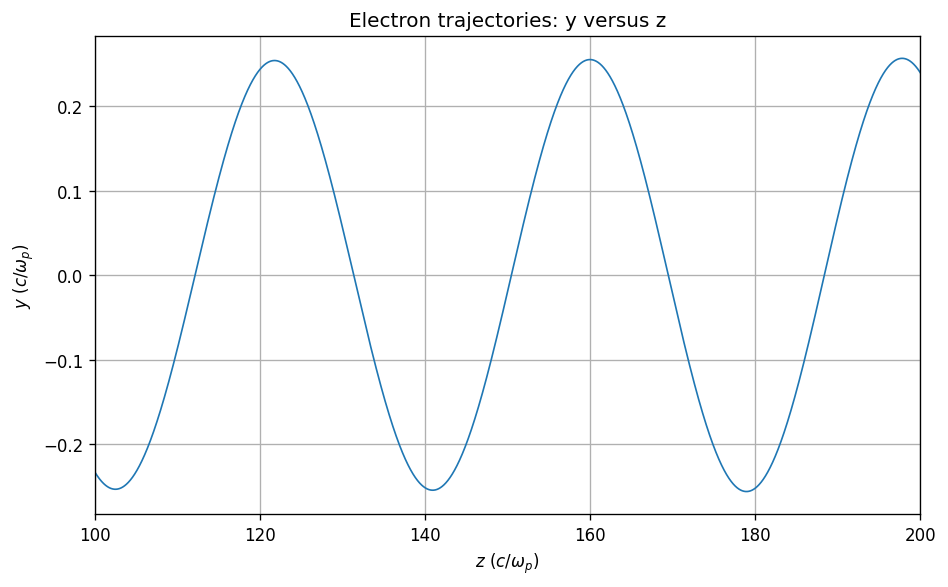

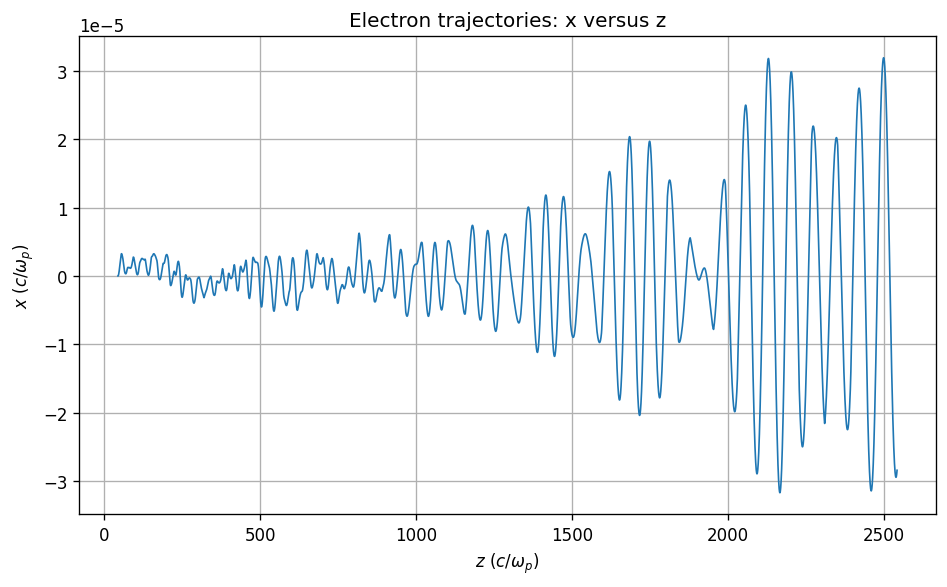

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# If your object is still called Debug and is a tuple containing one DebugObject,
# uncomment this line:
debug = Debug[0]

# Available fields inside Debug 
print("The Debug object contains the following saved simulation quantities:")
for key, value in debug.__dict__.items():
    print(f"{key:20s}  type={type(value).__name__:15s}  shape={np.shape(value)}")

# Pull trajectory data directly from the in-memory debug object
x_dat = np.asarray(debug.x_dat)
y_dat = np.asarray(debug.y_dat)
z_dat = np.asarray(debug.z_dat)
Fy_dat = np.asarray(debug.Fy_dat);

# Number of electrons
noElec = x_dat.shape[0]

print(f"\nPlotting {noElec} electron trajectory/trajectories.")

# ----------------------------
# Plot 1: y versus z
# ----------------------------
plt.figure(figsize=(8, 5), dpi=120)

for i in range(noElec):
    plt.plot(z_dat[i, :], y_dat[i, :], linewidth=1)

plt.xlim(100, 200)

plt.xlabel(r"$z$ $(c/\omega_p)$")
plt.ylabel(r"$y$ $(c/\omega_p)$")
plt.title("Electron trajectories: y versus z")
plt.grid(True)
plt.tight_layout()
plt.show()

# ----------------------------
# Plot 3: x versus z
# ----------------------------
plt.figure(figsize=(8, 5), dpi=120)

for i in range(noElec):
    plt.plot(z_dat[i, :], x_dat[i, :], linewidth=1)

plt.xlabel(r"$z$ $(c/\omega_p)$")
plt.ylabel(r"$x$ $(c/\omega_p)$")
plt.title("Electron trajectories: x versus z")
plt.grid(True)
plt.tight_layout()
plt.show()

### Loading Data
Next is loading data. Loading data can be done with the following simple code. Once it is loaded, you can do calculations, plotting etc. 

In [9]:
%reset -f
import pickle
import gc
import numpy as np
import matplotlib.pyplot as plt

gc.collect()

with open("data/betatron_tutorial_input-DEBUG.obj", "rb") as file:
    debug = pickle.load(file)[0]

print("The Debug object contains the following saved simulation quantities:")
for key, value in debug.__dict__.items():
    print(f"{key:20s}  type={type(value).__name__:15s}  shape={np.shape(value)}")





The Debug object contains the following saved simulation quantities:
x_dat                 type=ndarray          shape=(1, 500000)
y_dat                 type=ndarray          shape=(1, 500000)
z_dat                 type=ndarray          shape=(1, 500000)
xi_dat                type=ndarray          shape=(1, 500000)
Fx_dat                type=ndarray          shape=(1, 500000)
Fy_dat                type=ndarray          shape=(1, 500000)
Fz_dat                type=ndarray          shape=(1, 500000)
px_dat                type=ndarray          shape=(1, 500000)
py_dat                type=ndarray          shape=(1, 500000)
pz_dat                type=ndarray          shape=(1, 500000)


#### Post Processing (making the graphs!)
**If you have a more sophisticated code, you need to use index-mp, which uses multi-processor threading common on HPCs to load the data. It is not necessary for simple betatron test**

To run the post processing step you just enter 'python index-mp.py input.urInputFile' in your terminal. (But come back here after looking over the next few boxes)

##### Progressbar errors
Before running the final part of the betatron test you should be prepared to make a few edits to some files index-mp.py uses. Previously QuEP used a lot of a module called progressbar that for some reason doesn't work anymore. The easiest (though most time consuming way) to find all the progressbar parts is to just run the code and look at each error message. 
For each progressbar error go into the referenced file and comment out 'import progressbar' and check if progressbar is used anywhere in the code. If it is it likely is of the form 'for i in progressbar.progressbar(range(0,len(x_0)), redirect_stout=False):'. To change this all you keep is the 'for i in range(0,len(x_0)):' and don't forget to save the code after each edit.

##### Plot2DTracks edits
I've also included my plot2DTracks.py file below as there will probably be a few edits to make to that too. The most notable edit is in line ~41 I changed the GitHub version's 

"ax1.plot(x_dat[i,:], z_dat[i,:], 'k', label='$Z-X Trajectory') # Want vertical axis as y" 

to   "ax1.plot(z_dat[i,:], y_dat[i,:], 'k', label='$Z-X Trajectory') # Want vertical axis as y"

In [16]:
# Script for generating 2D plots of electron trajectories with option for plotting force

import numpy as np
import matplotlib.colors as col
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.ticker as ticker
from mpl_toolkits.mplot3d import Axes3D
import pdb

from numpy.core.fromnumeric import size
plt.rcParams.update({'font.size': 16})

plotYForce = True # Plot transverse force with trajectories, not useful for many trajectories
plotZForce = True # Plot force along WF propagation

#large_size = 12

#plt.rc('ytick', labelsize=large_size)
#plt.rc('axes', labelsize=large_size)

def make_patch_spines_invisible(ax):
    ax.set_frame_on(True)
    ax.patch.set_visible(False)
    for sp in ax.spines.values():
        sp.set_visible(False)

def plot(x_dat,y_dat,z_dat,xi_dat,Fx_dat,Fy_dat,Fz_dat,px_dat,py_dat,sim_name,shape_name,s1,s2,noElec,fname):

# 2D: Z-X, constrained to blowout regime THIS IS FIRST PLOT
    fig1 = plt.figure(1)
    ax1 = plt.axes()
    ax1.set_xlabel("Z ($c/\omega_p$)")
    ax1.set_ylabel("X ($c/\omega_p$)")
    ax1.set_xlim(0,600)
    ax1.tick_params(axis='y', labelcolor='k')
    ax1.set_title("Electron Trajectories through Blowout Regime")

    for i in range(0, noElec):
        ax1.plot(z_dat[i,:], y_dat[i,:], 'k', label='$Z-X Trajectory') # Want vertical axis as y

    if (plotZForce):
        ax1_f = ax1.twinx()
        ax1_f.set_ylabel("$F_z$ ($m_e c \omega_p$)")
        ax1_f.yaxis.label.set_color('C0')
        ax1_f.tick_params(axis='y', labelcolor='C0', colors='C0')

        for i in range(0, noElec):
            ax1_f.plot(z_dat[i,:], Fz_dat[i,:], 'C0', label='Z Force')

        fig1.legend(bbox_to_anchor=(0.88, 0.94), bbox_transform=plt.gcf().transFigure)

# 2D: Y-X THIS IS FOR SECOND PLOT
    fig2, ax2 = plt.subplots(1,figsize=(15,10),dpi=300)
    fig2.subplots_adjust(right=0.75)

    for i in range(0, noElec):
        #y_dat[i,:] = [y/0.65 for y in y_dat[i,:]]
        ax2.plot(x_dat[i,:], y_dat[i,:], 'k', label='Y-X Electron Trajectory') # Want vertical axis as y
        ax2.set_xlim(-1.5,1.5) #OG was (-10,10)
        ax2.set_ylim(-0.2,0.7)
    ax2.set_xlabel("X ($c/\omega_p$)")
    ax2.set_ylabel("Y/$R_b$ ($c/\omega_p$)")
    ax2.set_title("Electron Trajectory through Blowout Regime")

    if (plotYForce):
        Fy_ax = ax2.twinx()
        px_ax = ax2.twinx()
        py_ax = ax2.twinx()

        px_ax.spines["right"].set_position(("axes",1.15))
        make_patch_spines_invisible(px_ax)
        px_ax.spines["right"].set_visible(True)
        py_ax.spines["right"].set_position(("axes",1.3))
        make_patch_spines_invisible(py_ax)
        py_ax.spines["right"].set_visible(True)

        for i in range(0, noElec):
            Fy_ax.plot(x_dat[i,:], Fy_dat[i,:], 'C0', label='Transverse Electric Force, $F_y$')
            px_ax.plot(x_dat[i,:], px_dat[i,:], 'C1', label='Momentum in X')
            py_ax.plot(x_dat[i,:], py_dat[i,:], 'C2', label='Momentum in Y')
        Fy_ax.set_ylabel("$F_y$ ($m_e c \omega_p$)")
        px_ax.set_ylabel("$p_x (m_e c)$")
        py_ax.set_ylabel("$p_y (m_e c)$")

        Fy_ax.yaxis.label.set_color('C0')
        px_ax.yaxis.label.set_color('C1')
        py_ax.yaxis.label.set_color('C2')

        tkw = dict(size=4, width=1.5)
        ax2.tick_params(axis='y', colors='k', **tkw)
        Fy_ax.tick_params(axis='y', colors='C0', **tkw)
        px_ax.tick_params(axis='y', colors='C1', **tkw)
        py_ax.tick_params(axis='y', colors='C2', **tkw)
        ax2.tick_params(axis='x', **tkw)

        ax2.grid()
        fig2.legend(bbox_to_anchor=(0.3, 0.8), bbox_transform=plt.gcf().transFigure)

    fig1.tight_layout()
    fig1.show()
    fig2.tight_layout()
    fig2.savefig(f"eProbe-Trajectories_{fname}.png",transparent=False)
    fig1.savefig(f"eProbe-Trajectories1_{fname}.png",transparent=False)

/var/folders/5x/bhvnl00x2g3brb1rh5h_13p80000gn/T/ipykernel_54668/3097469762.py:12: DeprecationWarning: numpy.core.fromnumeric is deprecated and has been renamed to numpy._core.fromnumeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.fromnumeric.size.
  from numpy.core.fromnumeric import size


### The Graphs!
Once you've made the progressbar and plot2DTracks edits you are ready to run the 'making the graphs' step.
After running this you should see two files pop up in the left hand side directory of your folder on vs code. These two purple files are the images of your graphs. Once you have these copied and saved wherever you want you're free to delete them from your directory and you are finished!